# Smoking & Drinking — YOLOv8 Detection Data Preparation

**Scope :** build a clean, training-ready object-detection
dataset for the **smoking** and **drinking** classes. This notebook does *only* the data side —
**merge → validate → EDA → preprocess → augment → export** — and hands off a ready-to-train
Ultralytics YOLOv8 dataset (`data.yaml` + `images/` + `labels/`). Model training happens in a
separate notebook.
>
> This version **maps by class *name*** read from each dataset's `data.yaml`, keeps only
> smoking/drinking, and **drops every other class** (hands-on-wheel, sleeping, phone, …). Images
> that end up with no smoking/drinking box are removed, so the exported dataset contains **only
> smoking and drinking images**.



1. **Two datasets are harmonized by class name, not by index.** Two independently-labelled YOLO
   datasets almost never share the same class-index order. Mapping by index silently corrupts
   labels; we read each dataset's `names:` and remap **by name** into one unified schema.
2. **Non-target classes are dropped, not remapped.** Anything that isn't smoking or drinking
   (hands-on-wheel, sleeping, phone, safe-driving, …) is discarded so it can never masquerade as
   a target class.
3. **Validation before analysis.** Corrupt images, missing/malformed labels, out-of-range
   coordinates and genuinely unmapped classes are found and quarantined first.
4. **Split before augment.** We deduplicate, *then* split, *then* augment **train only**.
5. **Bounding-box-aware augmentation** via Albumentations (boxes transform with the pixels).
6. **Reproducible** — single global seed, deterministic split, one config cell.

### Pipeline

```
Drive ──> load & index both datasets ──> integrity validation ──> class harmonization (BY NAME)
      ──> drop non-target classes & empty images ──> EDA
      ──> clean ──> dedup ──> stratified split ──> augment TRAIN only ──> export YOLOv8
```

> Run top-to-bottom in Google Colab (GPU not required for prep). The only things you *must* edit
> are in the **Config** cell.

## 1 · Environment setup

Albumentations handles bbox-aware augmentation; PyYAML reads each dataset's `data.yaml`. Pinned
imports keep the run reproducible.

In [23]:
import os, sys, glob, shutil, random, hashlib, json, re, warnings
from pathlib import Path
from collections import Counter, defaultdict

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from PIL import Image, ImageFile
import cv2
import yaml
import albumentations as A
from tqdm.notebook import tqdm

warnings.filterwarnings("ignore")
ImageFile.LOAD_TRUNCATED_IMAGES = False   # we WANT truncated files to raise, so we can quarantine them
pd.set_option("display.max_columns", 60)

SEED = 42
random.seed(SEED); np.random.seed(SEED)

print("albumentations", A.__version__, "| opencv", cv2.__version__)

albumentations 2.0.8 | opencv 4.13.0


## 2 · Mount Google Drive

Both source datasets live in Drive. Mounting is read-only from our side — we only *read* the
originals and write everything new to a fresh output folder, so the raw data is never mutated.

In [24]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [25]:
import zipfile
from pathlib import Path

# WORK_DIR is defined in the Config cell (Section 3). If you run this cell first, set a default.
WORK_DIR = globals().get("WORK_DIR", "/content/work")
Path(WORK_DIR).mkdir(parents=True, exist_ok=True)

def unzip_dataset(zip_path, extract_to):
    if Path(extract_to).exists() and any(Path(extract_to).iterdir()):
        print(f"Skipping unzip for {zip_path}, target directory {extract_to} is not empty.")
        return
    with zipfile.ZipFile(zip_path, 'r') as zip_ref:
        zip_ref.extractall(extract_to)
    print(f"Unzipped {zip_path} to {extract_to}")

UNZIPPED_A_ROOT = Path(WORK_DIR) / "dataset_a_unzipped"
UNZIPPED_B_ROOT = Path(WORK_DIR) / "dataset_b_unzipped"
UNZIPPED_A_ROOT.mkdir(parents=True, exist_ok=True)
UNZIPPED_B_ROOT.mkdir(parents=True, exist_ok=True)

# Original zip file paths
ORIGINAL_DATASET_A_ZIP = "/content/drive/MyDrive/driver_project_work/stage-2-training-data-sleeping-smoking-and-hands-on-wheel.v6i.yolov8.zip"
ORIGINAL_DATASET_B_ZIP = "/content/drive/MyDrive/driver_project_work/archive (9).zip"

unzip_dataset(ORIGINAL_DATASET_A_ZIP, UNZIPPED_A_ROOT)
unzip_dataset(ORIGINAL_DATASET_B_ZIP, UNZIPPED_B_ROOT)

Skipping unzip for /content/drive/MyDrive/driver_project_work/stage-2-training-data-sleeping-smoking-and-hands-on-wheel.v6i.yolov8.zip, target directory /content/work/dataset_a_unzipped is not empty.
Skipping unzip for /content/drive/MyDrive/driver_project_work/archive (9).zip, target directory /content/work/dataset_b_unzipped is not empty.


## 3 · Configuration — **edit this cell only**

### Harmonization is done **by class name**, not by index

The earlier bug came from hardcoding source class **indices**. We no longer do that. Instead we
read each dataset's `data.yaml` (`names:` list) and map every source class **by name** onto the
unified schema using `CLASS_SYNONYMS`. Any class that is not a smoking/drinking synonym is
**dropped** automatically — so hands-on-wheel, sleeping, phone, etc. can never leak in as a
target class.

* Edit `CLASS_SYNONYMS` if your datasets use different words (e.g. `"has_bottle"` for drinking).
* Use `MANUAL_NAME_OVERRIDES` only for odd names a synonym set can't catch.
* Everything is printed in the next cell so you can **audit exactly what maps to what**.

In [26]:
# ════════════════ EDIT BELOW ════════════════

# --- Source dataset roots (unzipped in Section 2) ---
DATASET_A_ROOT = str(UNZIPPED_A_ROOT)
DATASET_B_ROOT = str(UNZIPPED_B_ROOT)

# --- Final unified label schema (index = position in this list) ---
UNIFIED_CLASSES = ["smoking", "drinking"]          # -> smoking=0, drinking=1

# --- Name-based harmonization -------------------------------------------------
# We map each source class to a unified class BY NAME. A source class name is
# normalized (lowercased, non-alphanumerics -> "_") and matched against these
# synonym sets. Anything that matches nothing is DROPPED (hands_on_wheel,
# sleeping, phone, safe_driving, ...). This is what removes the mislabelled
# "drinking" boxes that were really hands-on-wheel.
CLASS_SYNONYMS = {
    "smoking":  {"smoking", "smoke", "cigarette", "cig", "smoker"},
    "drinking": {"drinking", "drink", "drinks", "beverage", "bottle",
                 "drinking_water", "has_bottle"},
}

# Optional manual override for odd names. RAW source class name -> unified name
# (or None to force-drop). Leave the inner dicts empty to rely on CLASS_SYNONYMS.
MANUAL_NAME_OVERRIDES = {
    "A": {},   # e.g. {"hands on wheel": None}  (already dropped by default)
    "B": {},
}

# Keep ONLY images that contain at least one smoking/drinking box. With this
# False, images whose every box was a dropped non-target class are removed, so
# the exported dataset / report is purely smoking & drinking. Set True only if
# you deliberately want background/negative images in training.
KEEP_NEGATIVES = False

# --- Output (fresh, non-destructive) ---
OUTPUT_ROOT = "/content/drive/MyDrive/datasets/smoking_drinking_yolo"  # final dataset
WORK_DIR    = "/content/work"                                          # fast local scratch

# --- Split ratios (must sum to 1.0) ---
SPLIT = {"train": 0.80, "val": 0.10, "test": 0.10}

# --- Augmentation: offline copies added to TRAIN only ---
AUG_PER_IMAGE   = 2        # augmented variants generated per training image
BALANCE_CLASSES = True     # give minority-class images extra augmentation
IMG_EXTS        = (".jpg", ".jpeg", ".png", ".bmp", ".webp")

# ════════════════ EDIT ABOVE ════════════════

CLASS_TO_ID = {c: i for i, c in enumerate(UNIFIED_CLASSES)}
ID_TO_CLASS = {i: c for c, i in CLASS_TO_ID.items()}
assert abs(sum(SPLIT.values()) - 1.0) < 1e-6, "SPLIT must sum to 1.0"
Path(WORK_DIR).mkdir(parents=True, exist_ok=True)
print("Unified classes:", CLASS_TO_ID)

Unified classes: {'smoking': 0, 'drinking': 1}


### 3.1 Read each dataset's real class names and build a name-based map

This cell reads `data.yaml` (or `classes.txt`) from each dataset root, then prints the exact
source-id → unified-name mapping it will use. **Read this output** — it is the single most
important audit in the pipeline. Every dropped class is shown as `DROP`.

In [27]:
def _norm(name: str) -> str:
    """lowercase, collapse non-alphanumerics to underscore."""
    return re.sub(r"[^a-z0-9]+", "_", str(name).strip().lower()).strip("_")

# invert synonyms -> unified (all normalized)
_SYN_TO_UNIFIED = {}
for _unified, _syns in CLASS_SYNONYMS.items():
    for _s in _syns:
        _SYN_TO_UNIFIED[_norm(_s)] = _unified


def read_class_names(root: str) -> dict:
    """Return {src_id: raw_name} from data.yaml (Ultralytics) or classes.txt."""
    root = Path(root)
    yamls = list(root.rglob("data.yaml")) + [y for y in root.rglob("*.yaml")
                                             if y.name != "data.yaml"]
    for yml in sorted(yamls):
        try:
            d = yaml.safe_load(yml.read_text())
        except Exception:
            continue
        names = d.get("names") if isinstance(d, dict) else None
        if isinstance(names, dict):                       # {0: 'smoking', ...}
            return {int(k): str(v) for k, v in names.items()}
        if isinstance(names, list):                       # ['smoking', ...]
            return {i: str(v) for i, v in enumerate(names)}
    for ct in sorted(root.rglob("classes.txt")):          # fallback
        lines = [l.strip() for l in ct.read_text().splitlines() if l.strip()]
        if lines:
            return {i: n for i, n in enumerate(lines)}
    raise FileNotFoundError(
        f"No data.yaml / classes.txt with class names found under {root}. "
        f"Add one, or fill MANUAL_NAME_OVERRIDES.")


def build_class_map(root: str, source_tag: str) -> dict:
    """src_id -> unified_name or None (None = drop this class)."""
    raw = read_class_names(root)
    overrides = {_norm(k): v for k, v in MANUAL_NAME_OVERRIDES.get(source_tag, {}).items()}
    cmap = {}
    print(f"\n[{source_tag}] classes declared in data.yaml: {raw}")
    for cid, rawname in raw.items():
        key = _norm(rawname)
        if key in overrides:
            unified = overrides[key]
        else:
            unified = _SYN_TO_UNIFIED.get(key)            # None if not a target class
        cmap[cid] = unified
        print(f"    {source_tag}:{cid:>2}  '{rawname}'  ->  {unified if unified else 'DROP'}")
    kept = [v for v in cmap.values() if v]
    bad = set(kept) - set(UNIFIED_CLASSES)
    assert not bad, f"[{source_tag}] mapped to class(es) outside UNIFIED_CLASSES: {bad}"
    if "drinking" not in kept:
        print(f"    ⚠ dataset {source_tag} contributes NO drinking boxes "
              f"(no drink/drinking-type class in its data.yaml).")
    if "smoking" not in kept:
        print(f"    ⚠ dataset {source_tag} contributes NO smoking boxes.")
    return cmap


DATASET_A_CLASS_MAP = build_class_map(DATASET_A_ROOT, "A")
DATASET_B_CLASS_MAP = build_class_map(DATASET_B_ROOT, "B")

print("\nUnified target schema:", CLASS_TO_ID)


[A] classes declared in data.yaml: {0: 'Hands on Wheel', 1: 'Smoking'}
    A: 0  'Hands on Wheel'  ->  DROP
    A: 1  'Smoking'  ->  smoking
    ⚠ dataset A contributes NO drinking boxes (no drink/drinking-type class in its data.yaml).

[B] classes declared in data.yaml: {0: 'drinking', 1: 'smoking'}
    B: 0  'drinking'  ->  drinking
    B: 1  'smoking'  ->  smoking

Unified target schema: {'smoking': 0, 'drinking': 1}


## 4 · Load & index both datasets

We build one tidy **instance-level** dataframe. For every image we locate its YOLO label, keep
only boxes whose source class maps to a target class, and **drop the rest**. An image whose boxes
are *all* dropped is recorded once as a negative (`status="no_target_class"`) so it can be
excluded later. A class id present in a label but absent from `data.yaml` is flagged `UNMAPPED`
(a genuine anomaly, not an intentional drop).

In [28]:
def find_label_for_image(img_path: Path) -> Path:
    """YOLO convention: same stem .txt, preferring a parallel /labels/ dir."""
    stem_txt = img_path.with_suffix(".txt").name
    candidates = [
        img_path.with_suffix(".txt"),
        Path(str(img_path.parent).replace("/images", "/labels")) / stem_txt,
        Path(str(img_path.parent).replace("\\images", "\\labels")) / stem_txt,
        img_path.parent.parent / "labels" / stem_txt,
    ]
    for c in candidates:
        if c.exists():
            return c
    return candidates[0]


def parse_yolo_label(label_path: Path):
    """Return (list of (cls_id, xc, yc, w, h), status)."""
    rows = []
    if not label_path.exists():
        return rows, "missing_label"
    text = label_path.read_text().strip()
    if text == "":
        return rows, "empty_label"          # valid background/negative image
    for ln in text.splitlines():
        parts = ln.split()
        if len(parts) != 5:
            return rows, "malformed_line"
        cid, xc, yc, w, h = parts
        rows.append((int(float(cid)), float(xc), float(yc), float(w), float(h)))
    return rows, "ok"


def index_dataset(root: str, source: str, class_map: dict) -> pd.DataFrame:
    root = Path(root)
    assert root.exists(), f"Dataset root not found: {root}"
    imgs = [p for p in root.rglob("*") if p.suffix.lower() in IMG_EXTS]
    print(f"[{source}] {len(imgs)} images found under {root}")

    records = []
    n_dropped_boxes = 0
    for img in imgs:
        lbl = find_label_for_image(img)
        boxes, status = parse_yolo_label(lbl)

        if status in ("missing_label", "malformed_line"):
            records.append(dict(source=source, image=str(img), label=str(lbl),
                                 src_cls=None, unified_cls=None,
                                 xc=None, yc=None, w=None, h=None, status=status))
            continue

        kept = []
        for cid, xc, yc, w, h in boxes:
            if cid in class_map:
                unified = class_map[cid]
                if unified is None:
                    n_dropped_boxes += 1        # intentional drop (non-target class)
                    continue
                kept.append((cid, unified, xc, yc, w, h))
            else:
                kept.append((cid, "UNMAPPED", xc, yc, w, h))   # genuine anomaly -> flagged

        if kept:
            for cid, unified, xc, yc, w, h in kept:
                records.append(dict(source=source, image=str(img), label=str(lbl),
                                     src_cls=cid, unified_cls=unified,
                                     xc=xc, yc=yc, w=w, h=h, status="ok"))
        else:
            # no target boxes survived: empty label, or every box was a dropped class
            neg_status = "empty_label" if status == "empty_label" else "no_target_class"
            records.append(dict(source=source, image=str(img), label=str(lbl),
                                 src_cls=None, unified_cls=None,
                                 xc=None, yc=None, w=None, h=None, status=neg_status))

    print(f"[{source}] non-target boxes dropped: {n_dropped_boxes:,}")
    return pd.DataFrame(records)


df_a = index_dataset(DATASET_A_ROOT, "A", DATASET_A_CLASS_MAP)
df_b = index_dataset(DATASET_B_ROOT, "B", DATASET_B_CLASS_MAP)
df = pd.concat([df_a, df_b], ignore_index=True)
print(f"\nTotal rows (instances + flags): {len(df):,}")
df.head()

[A] 17902 images found under /content/work/dataset_a_unzipped
[A] non-target boxes dropped: 7,159
[B] 1030 images found under /content/work/dataset_b_unzipped
[B] non-target boxes dropped: 0

Total rows (instances + flags): 21,923


,source,image,label,src_cls,unified_cls,xc,yc,w,h,status
0,A,/content/work/dataset_a_unzipped/test/images/i...,/content/work/dataset_a_unzipped/test/labels/i...,NaN,None,NaN,NaN,NaN,NaN,no_target_class
1,A,/content/work/dataset_a_unzipped/test/images/m...,/content/work/dataset_a_unzipped/test/labels/m...,1.0,smoking,0.860156,0.571875,0.043750,0.029687,ok
2,A,/content/work/dataset_a_unzipped/test/images/m...,/content/work/dataset_a_unzipped/test/labels/m...,1.0,smoking,0.482031,0.542969,0.078125,0.084375,ok
3,A,/content/work/dataset_a_unzipped/test/images/m...,/content/work/dataset_a_unzipped/test/labels/m...,1.0,smoking,0.584375,0.439844,0.090625,0.050000,ok
4,A,/content/work/dataset_a_unzipped/test/images/m...,/content/work/dataset_a_unzipped/test/labels/m...,1.0,smoking,0.126562,0.548438,0.070312,0.042188,ok


## 5 · Integrity validation & quarantine

Per image we check: **decodability** (PIL can open & verify pixels), **label presence**
(missing vs. empty vs. malformed), **coordinate sanity** (normalized to `[0,1]`, non-zero size),
and **unmapped classes** (a class id in a label file that isn't in that dataset's `data.yaml`).
Everything failing goes to `bad_images` and is excluded downstream — nothing is deleted from
Drive. Intentionally dropped non-target classes are **not** errors and are not counted here.

In [29]:
# 5a. Image decodability (verify once per unique image)
unique_imgs = df["image"].unique()
corrupt = set()
img_dims = {}
for p in unique_imgs:
    try:
        with Image.open(p) as im:
            im.verify()
        with Image.open(p) as im:
            img_dims[p] = im.size
    except Exception:
        corrupt.add(p)
print(f"Corrupt/undecodable images: {len(corrupt)}")

df["img_w"] = df["image"].map(lambda p: img_dims.get(p, (np.nan, np.nan))[0])
df["img_h"] = df["image"].map(lambda p: img_dims.get(p, (np.nan, np.nan))[1])

# 5b. Coordinate sanity on real boxes
def coord_ok(r):
    if r["status"] != "ok":
        return True
    vals = [r["xc"], r["yc"], r["w"], r["h"]]
    if any(v is None or not (0.0 <= v <= 1.0) for v in vals):
        return False
    return r["w"] > 0 and r["h"] > 0
df["coord_ok"] = df.apply(coord_ok, axis=1)

# 5c. Assemble the problem set
issues = []
issues.append(("corrupt image",        df["image"].isin(corrupt)))
issues.append(("missing label",        df["status"].eq("missing_label")))
issues.append(("malformed label",      df["status"].eq("malformed_line")))
issues.append(("bad coordinates",      ~df["coord_ok"]))
issues.append(("unmapped class",       df["unified_cls"].eq("UNMAPPED")))

print("\n── Data quality report ──")
report = {name: int(mask.sum()) for name, mask in issues}
report["empty (negative) labels"]        = int(df["status"].eq("empty_label").sum())
report["dropped non-target-only images"] = int(df["status"].eq("no_target_class").sum())
display(pd.Series(report, name="count").to_frame())

bad_mask = (df["image"].isin(corrupt) | df["status"].isin(["missing_label", "malformed_line"])
            | ~df["coord_ok"] | df["unified_cls"].eq("UNMAPPED"))
bad_images = set(df.loc[bad_mask, "image"])
print(f"\nImages quarantined (any issue): {len(bad_images)}")

Corrupt/undecodable images: 0

── Data quality report ──


,count
corrupt image,0
missing label,0
malformed label,0
bad coordinates,0
unmapped class,0
empty (negative) labels,318
dropped non-target-only images,5705



Images quarantined (any issue): 0


## 6 · Class harmonization → clean instance table

We drop quarantined images and keep only real smoking/drinking boxes. If `KEEP_NEGATIVES` is
`False` (default), images with no target box are excluded entirely, so the dataset holds **only
smoking and drinking images**. `inst` is the trustworthy per-box table used by every chart and
the export.

In [30]:
clean = df[(df["status"] == "ok") & (~df["image"].isin(bad_images))].copy()
clean["cls_id"]   = clean["unified_cls"].map(CLASS_TO_ID)
clean["cls_name"] = clean["unified_cls"]

# Keep only the classes we actually train on (defensive; UNMAPPED already gone)
clean = clean[clean["cls_name"].isin(UNIFIED_CLASSES)].copy()

# derived box geometry (normalized units)
clean["area"]   = clean["w"] * clean["h"]
clean["aspect"] = clean["w"] / clean["h"].replace(0, np.nan)

inst = clean.reset_index(drop=True)

# Optionally retain negative images (no target box) as background samples.
negative_images = set()
if KEEP_NEGATIVES:
    neg = df[df["status"].isin(["empty_label", "no_target_class"])
             & (~df["image"].isin(bad_images))
             & (~df["image"].isin(set(inst["image"])))]
    negative_images = set(neg["image"])
    print(f"Retaining {len(negative_images):,} negative/background images (KEEP_NEGATIVES=True).")
else:
    print("KEEP_NEGATIVES=False → keeping only images that contain smoking/drinking.")

n_imgs = inst["image"].nunique()
print(f"\nClean target instances: {len(inst):,} across {n_imgs:,} images")
print("Instances per class:")
display(inst["cls_name"].value_counts().reindex(UNIFIED_CLASSES).fillna(0).astype(int)
        .to_frame("instances"))

for c in UNIFIED_CLASSES:
    if int((inst["cls_name"] == c).sum()) == 0:
        print(f"⚠ No '{c}' instances survived. Check the Section 3.1 map — none of your "
              f"source classes matched a '{c}' synonym.")

KEEP_NEGATIVES=False → keeping only images that contain smoking/drinking.

Clean target instances: 15,900 across 12,909 images
Instances per class:


,instances
cls_name,
smoking,15127
drinking,773


## 7 · Exploratory Data Analysis

Organized around the questions that decide detector behavior: class balance, scene crowding, box
geometry, spatial prior, cross-dataset agreement, and a visual gut-check. All charts iterate over
whichever target classes are actually present, so nothing breaks if (say) drinking is absent.

### 7.1 Class balance — instances vs. images

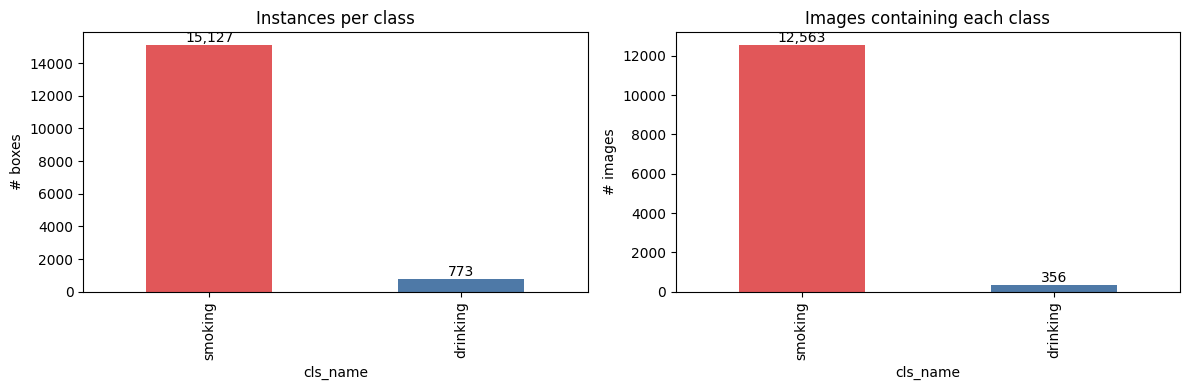

Instance imbalance ratio (max/min): 19.57x
→ Notable imbalance. Class-balanced augmentation (Section 10) will help even this out.


In [31]:
present = [c for c in UNIFIED_CLASSES if (inst["cls_name"] == c).any()]
palette = {"smoking": "#e15759", "drinking": "#4e79a7"}
colors  = [palette.get(c, "#59a14f") for c in present]

fig, ax = plt.subplots(1, 2, figsize=(12, 4))

inst["cls_name"].value_counts().reindex(present).plot(kind="bar", ax=ax[0], color=colors)
ax[0].set_title("Instances per class"); ax[0].set_ylabel("# boxes")
for i, v in enumerate(inst["cls_name"].value_counts().reindex(present)):
    ax[0].text(i, v, f"{int(v):,}", ha="center", va="bottom")

img_per_cls = inst.groupby("cls_name")["image"].nunique().reindex(present)
img_per_cls.plot(kind="bar", ax=ax[1], color=colors)
ax[1].set_title("Images containing each class"); ax[1].set_ylabel("# images")
for i, v in enumerate(img_per_cls):
    ax[1].text(i, v, f"{int(v):,}", ha="center", va="bottom")

plt.tight_layout(); plt.show()

imbalance = inst["cls_name"].value_counts()
if len(imbalance) >= 2:
    ratio = imbalance.max() / imbalance.min()
    print(f"Instance imbalance ratio (max/min): {ratio:.2f}x")
    if ratio > 1.5:
        print("→ Notable imbalance. Class-balanced augmentation (Section 10) will help even this out.")
else:
    print("Only one target class present — imbalance ratio not applicable.")

### 7.2 Boxes per image — how crowded are scenes?

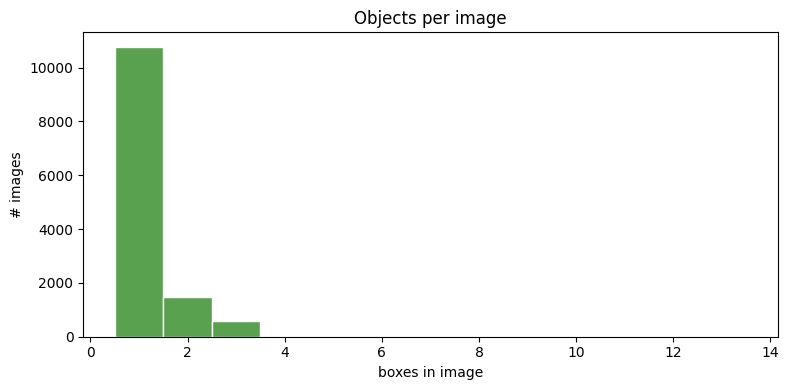

count    12909.00
mean         1.23
std          0.62
min          1.00
25%          1.00
50%          1.00
75%          1.00
max         13.00


In [32]:
boxes_per_img = inst.groupby("image").size()
fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(boxes_per_img, bins=range(1, boxes_per_img.max() + 2), align="left",
        color="#59a14f", edgecolor="white")
ax.set_title("Objects per image"); ax.set_xlabel("boxes in image"); ax.set_ylabel("# images")
plt.tight_layout(); plt.show()
print(boxes_per_img.describe().round(2).to_string())

### 7.3 Bounding-box geometry & small-object analysis

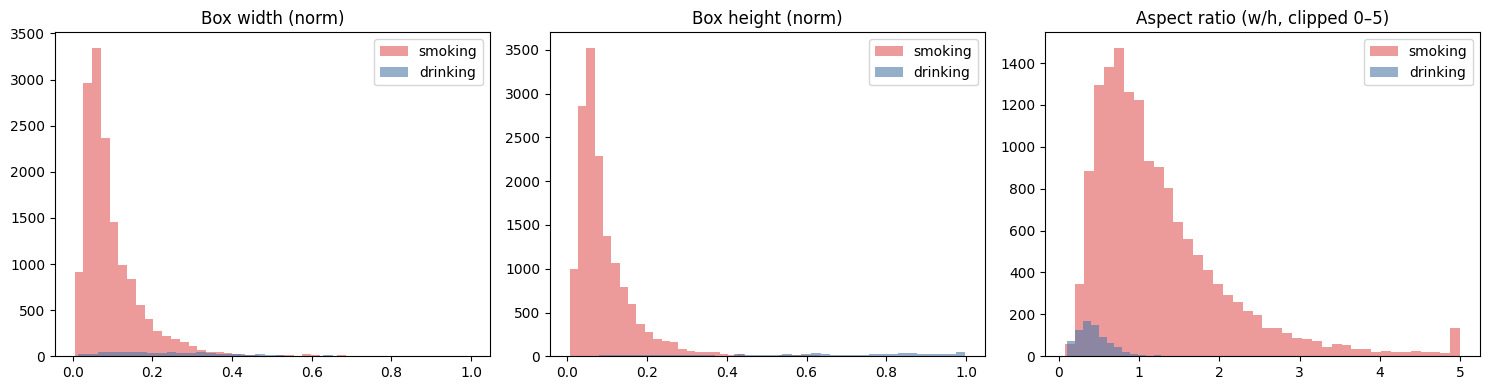

cls_name,drinking,smoking
size_bucket,,
tiny (<1%),49,10533
small (1–5%),115,3926
medium (5–15%),202,552
large (>15%),407,116


Share of tiny boxes (<1% of image): 66.6%
→ Many small objects: prefer a larger imgsz (e.g. 832/960) and avoid heavy downscaling.


In [33]:
fig, ax = plt.subplots(1, 3, figsize=(15, 4))
for cname in present:
    color = palette.get(cname, "#59a14f")
    sub = inst[inst["cls_name"] == cname]
    ax[0].hist(sub["w"], bins=40, alpha=0.6, label=cname, color=color)
    ax[1].hist(sub["h"], bins=40, alpha=0.6, label=cname, color=color)
    ax[2].hist(np.clip(sub["aspect"], 0, 5), bins=40, alpha=0.6, label=cname, color=color)
ax[0].set_title("Box width (norm)");  ax[1].set_title("Box height (norm)")
ax[2].set_title("Aspect ratio (w/h, clipped 0–5)")
for a in ax: a.legend()
plt.tight_layout(); plt.show()

def bucket(a):
    if a < 0.01: return "tiny (<1%)"
    if a < 0.05: return "small (1–5%)"
    if a < 0.15: return "medium (5–15%)"
    return "large (>15%)"
inst["size_bucket"] = inst["area"].map(bucket)
order = ["tiny (<1%)", "small (1–5%)", "medium (5–15%)", "large (>15%)"]
display(pd.crosstab(inst["size_bucket"], inst["cls_name"]).reindex(order))
tiny_share = (inst["area"] < 0.01).mean()
print(f"Share of tiny boxes (<1% of image): {tiny_share:.1%}")
if tiny_share > 0.15:
    print("→ Many small objects: prefer a larger imgsz (e.g. 832/960) and avoid heavy downscaling.")

### 7.4 Spatial prior — where do objects sit in the frame?

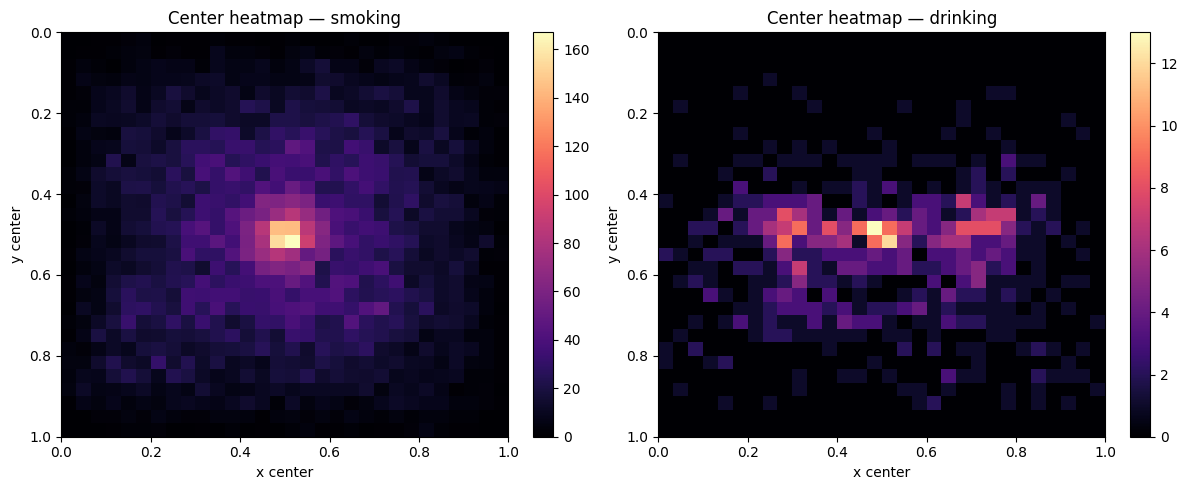

In [34]:
cls_for_maps = present if present else UNIFIED_CLASSES
fig, ax = plt.subplots(1, len(cls_for_maps), figsize=(6 * len(cls_for_maps), 5))
if len(cls_for_maps) == 1: ax = [ax]
for a, cname in zip(ax, cls_for_maps):
    sub = inst[inst["cls_name"] == cname]
    h = a.hist2d(sub["xc"], sub["yc"], bins=30, range=[[0, 1], [0, 1]], cmap="magma")
    a.set_title(f"Center heatmap — {cname}")
    a.set_xlabel("x center"); a.set_ylabel("y center"); a.invert_yaxis()
    fig.colorbar(h[3], ax=a, fraction=0.046)
plt.tight_layout(); plt.show()

### 7.5 Per-dataset comparison — domain / annotation-style shift

If A and B disagree sharply on box sizes or resolution, the model may overfit to one source's
style. This is the check a naive "just concat them" workflow skips.

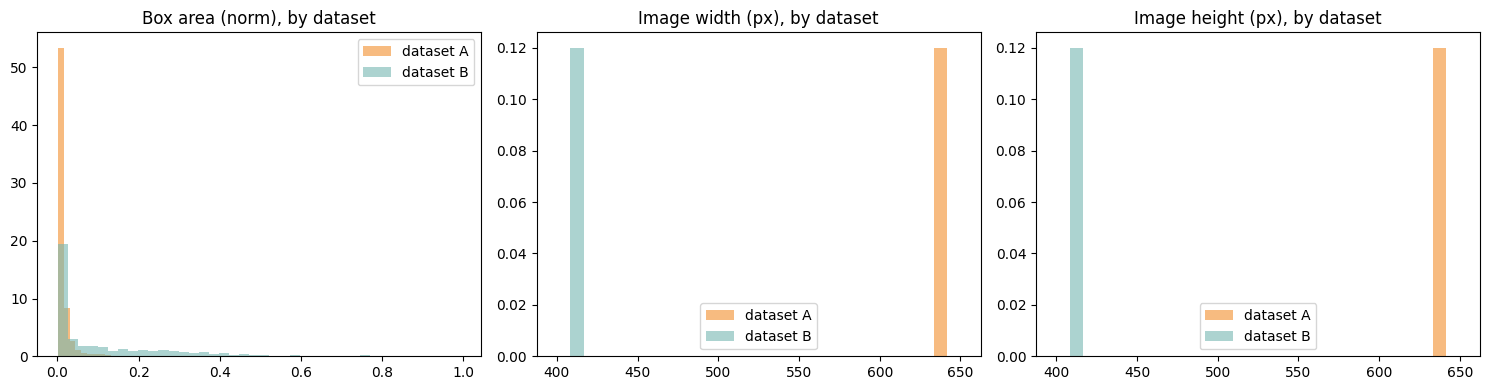

Class share by dataset:


cls_name,drinking,smoking
source,,
A,0.000,1.000
B,0.523,0.477


In [35]:
fig, ax = plt.subplots(1, 3, figsize=(15, 4))
for s, color in zip(["A", "B"], ["#f28e2b", "#76b7b2"]):
    sub = inst[inst["source"] == s]
    if sub.empty:
        continue
    ax[0].hist(sub["area"], bins=40, alpha=0.6, label=f"dataset {s}", color=color, density=True)
    ax[1].hist(sub["img_w"].dropna(), bins=30, alpha=0.6, label=f"dataset {s}", color=color, density=True, range=(400, 650))
    ax[2].hist(sub["img_h"].dropna(), bins=30, alpha=0.6, label=f"dataset {s}", color=color, density=True, range=(400, 650))
ax[0].set_title("Box area (norm), by dataset")
ax[1].set_title("Image width (px), by dataset")
ax[2].set_title("Image height (px), by dataset")
for a in ax: a.legend()
plt.tight_layout(); plt.show()

print("Class share by dataset:")
display(pd.crosstab(inst["source"], inst["cls_name"], normalize="index").round(3))

### 7.6 Visual sanity check — sample images with boxes drawn

The most direct confirmation the fix worked: every drawn box should genuinely be smoking or
drinking, with **no hands-on-wheel boxes labelled as drinking**.

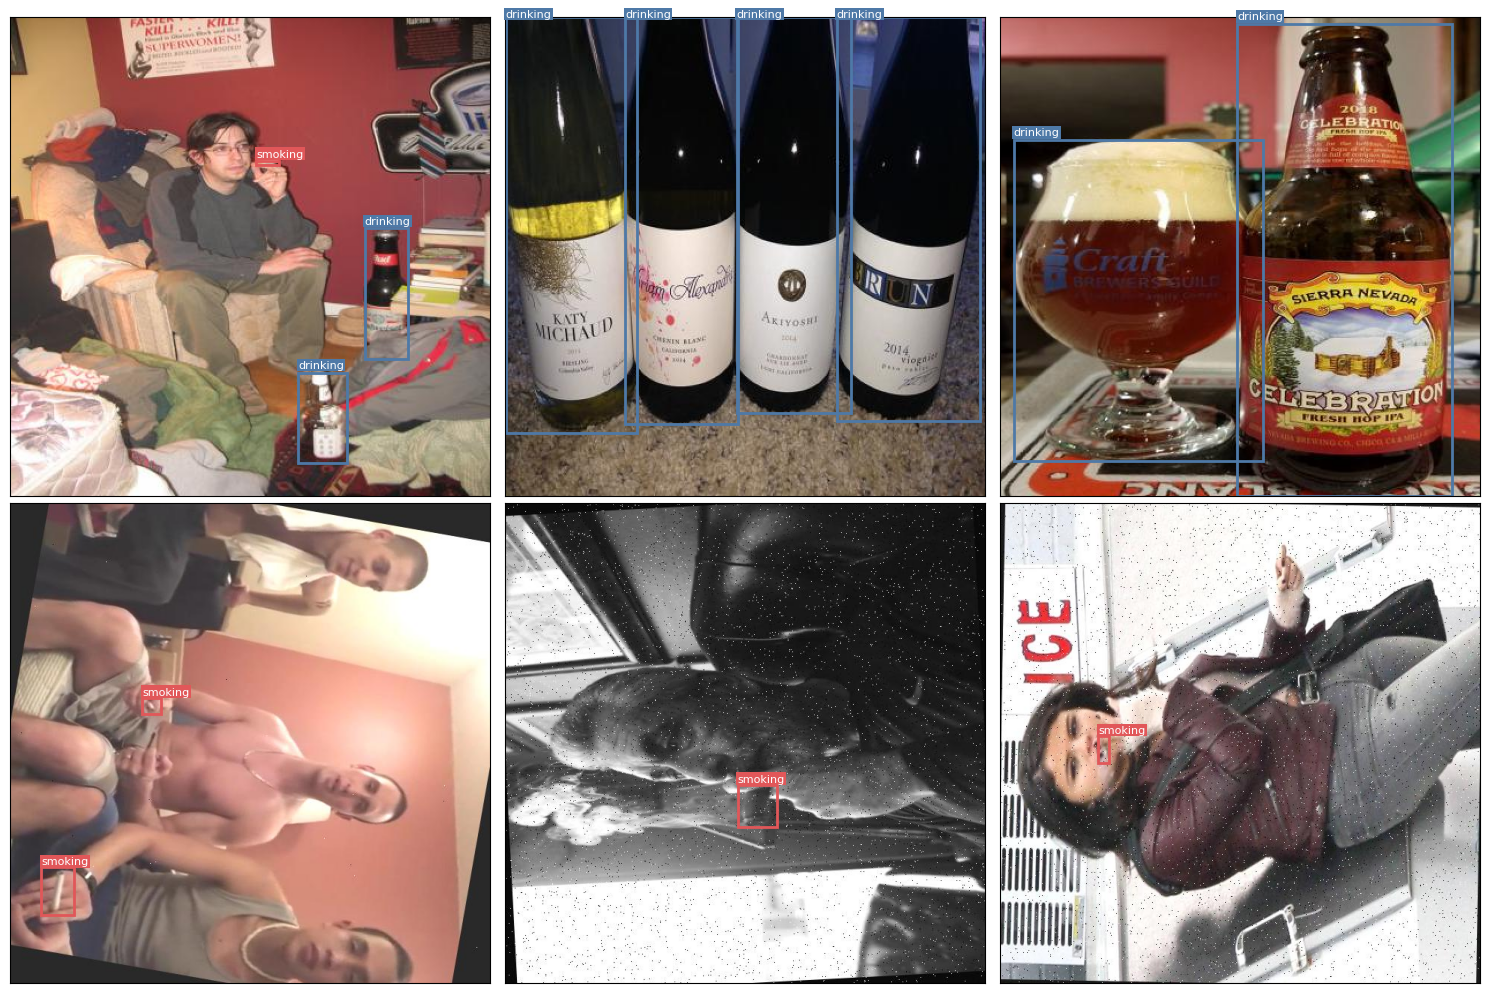

In [36]:
def draw_sample(image_path, ax):
    im = cv2.cvtColor(cv2.imread(image_path), cv2.COLOR_BGR2RGB)
    H, W = im.shape[:2]
    ax.imshow(im)
    for _, r in inst[inst["image"] == image_path].iterrows():
        x = (r["xc"] - r["w"] / 2) * W; y = (r["yc"] - r["h"] / 2) * H
        rect = patches.Rectangle((x, y), r["w"] * W, r["h"] * H,
                                 linewidth=2, edgecolor=palette.get(r["cls_name"], "lime"),
                                 facecolor="none")
        ax.add_patch(rect)
        ax.text(x, max(y - 4, 0), r["cls_name"], color="white", fontsize=8,
                bbox=dict(facecolor=palette.get(r["cls_name"], "lime"), pad=1, edgecolor="none"))
    ax.set_xticks([]); ax.set_yticks([])

sample_imgs = (inst.groupby("cls_name")["image"].apply(
    lambda s: list(pd.Series(s.unique()).sample(min(3, s.nunique()), random_state=SEED)))
    ).explode().dropna().unique()[:6]

n = len(sample_imgs)
if n:
    fig, axes = plt.subplots((n + 2) // 3, 3, figsize=(15, 5 * ((n + 2) // 3)))
    for ax, p in zip(np.array(axes).ravel(), sample_imgs):
        draw_sample(p, ax)
    for ax in np.array(axes).ravel()[n:]:
        ax.axis("off")
    plt.tight_layout(); plt.show()
else:
    print("No target images to display.")

## 8 · Deduplication (before splitting)

Merged datasets frequently share frames. We perceptual-hash every image and keep one
representative per hash cluster, so duplicates cannot land on both sides of the split.

In [37]:
import imagehash
all_pool = set(inst["image"].unique()) | negative_images
hash_map = defaultdict(list)
for p in all_pool:
    try:
        with Image.open(p) as im:
            hash_map[str(imagehash.phash(im))].append(p)
    except Exception:
        pass

dupes = {h: ps for h, ps in hash_map.items() if len(ps) > 1}
keep_images = {ps[0] for ps in hash_map.values()}
n_dropped = len(all_pool) - len(keep_images)
print(f"Duplicate clusters: {len(dupes)} | images dropped as duplicates: {n_dropped}")

inst = inst[inst["image"].isin(keep_images)].reset_index(drop=True)
negative_images = negative_images & keep_images
print(f"Target images after dedup: {inst['image'].nunique():,}"
      + (f" | negative images: {len(negative_images):,}" if KEEP_NEGATIVES else ""))

Duplicate clusters: 492 | images dropped as duplicates: 521
Target images after dedup: 12,388


## 9 · Train / val / test split (image-grouped, class-stratified)

Split at the **image** level (all boxes of an image stay together), stratified by each image's
**dominant class**. Negative images (if kept) are stratified as their own group. Deterministic
via `SEED`.

In [38]:
# dominant class per target image
img_dom = (inst.groupby("image")["cls_name"]
                .agg(lambda s: s.value_counts().idxmax())
                .rename("dom_cls").reset_index())

# include negatives as their own stratum
if negative_images:
    img_dom = pd.concat([img_dom,
        pd.DataFrame({"image": list(negative_images), "dom_cls": "background"})],
        ignore_index=True)

rng = np.random.default_rng(SEED)
assign = {}
for cls, grp in img_dom.groupby("dom_cls"):
    imgs = grp["image"].tolist(); rng.shuffle(imgs)
    n = len(imgs)
    n_tr = int(round(n * SPLIT["train"]))
    n_va = int(round(n * SPLIT["val"]))
    for i, im in enumerate(imgs):
        assign[im] = "train" if i < n_tr else ("val" if i < n_tr + n_va else "test")

inst["split"] = inst["image"].map(assign)
print("Target images per split:")
display(inst.groupby("split")["image"].nunique().reindex(["train", "val", "test"]).to_frame("images"))
print("\nInstances per class per split:")
display(pd.crosstab(inst["split"], inst["cls_name"]).reindex(["train", "val", "test"]))

Target images per split:


,images
split,
train,9910
val,1239
test,1239



Instances per class per split:


cls_name,drinking,smoking
split,,
train,636,11696
val,64,1447
test,73,1441


## 10 · Augmentation — **train split only**, bbox-aware

Albumentations transforms images and their boxes together. Only label-preserving ops are used:
geometric flips/scale/rotate plus photometric jitter. **No vertical flips**, rotation kept mild.
If `BALANCE_CLASSES`, minority-class images get extra augmented copies.

In [39]:
transform = A.Compose([
    A.HorizontalFlip(p=0.5),
    A.Affine(scale=(0.85, 1.15), translate_percent=(0.0, 0.06),
             rotate=(-12, 12), shear=(-4, 4), fit_output=False, p=0.7),
    A.RandomBrightnessContrast(brightness_limit=0.2, contrast_limit=0.2, p=0.6),
    A.HueSaturationValue(hue_shift_limit=10, sat_shift_limit=20, val_shift_limit=15, p=0.4),
    A.OneOf([A.MotionBlur(blur_limit=5), A.GaussianBlur(blur_limit=5),
             A.GaussNoise(var_limit=(10, 40))], p=0.3),
    A.CLAHE(clip_limit=2.0, p=0.2),
], bbox_params=A.BboxParams(format="yolo", label_fields=["class_labels"],
                            min_visibility=0.3, min_area=1e-4))

cls_counts = inst[inst.split == "train"]["cls_name"].value_counts()
minority = cls_counts.idxmin() if (BALANCE_CLASSES and len(cls_counts) >= 2) else None
extra_for_minority = (int(round(cls_counts.max() / max(cls_counts.min(), 1))) - 1
                      if minority else 0)
print("Base aug/image:", AUG_PER_IMAGE, "| minority class:", minority,
      "| extra copies for minority images:", extra_for_minority)

Base aug/image: 2 | minority class: drinking | extra copies for minority images: 17


## 11 · Export the YOLOv8 dataset → download to your laptop

Everything is written to **fast local disk** (not Drive), zipped once, and then pushed to your
browser as a download. Originals are copied byte-for-byte (no re-encode); augmented variants go
**only into `train/`** as JPEG. If the browser download is blocked (common for very large files),
the zip also stays in the Colab file browser so you can download it manually.

In [40]:
import concurrent.futures, os, cv2, shutil
from pathlib import Path
from tqdm.notebook import tqdm

cv2.setNumThreads(0)  # avoid thread oversubscription across worker processes

# ── Write to local SSD (fast), NOT Drive ─────────────────────────────────────
DATASET_NAME = "smoking_drinking_yolo"
out = Path(WORK_DIR) / DATASET_NAME
if out.exists():
    shutil.rmtree(out)
for sub in ["images", "labels"]:
    for sp in ["train", "val", "test"]:
        (out / sub / sp).mkdir(parents=True, exist_ok=True)

JPEG_Q, AUG_AS_JPG = 90, True   # augmented copies as .jpg = faster + smaller than .png

def write_label(path, boxes):
    path.write_text("\n".join(f"{c} {x:.6f} {y:.6f} {w:.6f} {h:.6f}"
                              for c, x, y, w, h in boxes))

# group boxes per image without iterrows()
per_image = {img: list(zip(g.cls_id.astype(int), g.xc, g.yc, g.w, g.h))
             for img, g in inst.groupby("image")}
img_split = dict(zip(inst["image"], inst["split"]))
for p in negative_images:
    per_image.setdefault(p, []); img_split[p] = assign[p]

img_dom_map = dict(zip(img_dom["image"], img_dom["dom_cls"]))
src_tag = dict(zip(inst["image"], inst["source"]))
for p in negative_images:
    src_tag.setdefault(p, "A" if "dataset_a" in str(p) else "B")

def process_single_image(img_path):
    boxes = per_image[img_path]
    sp = img_split[img_path]
    stem = f"{src_tag.get(img_path, 'X')}_{Path(img_path).stem}"
    ext = Path(img_path).suffix.lower()
    shutil.copy(img_path, out / "images" / sp / f"{stem}{ext}")   # raw byte copy
    write_label(out / "labels" / sp / f"{stem}.txt", boxes)
    n_written, n_aug = 1, 0
    if sp == "train" and boxes:
        reps = AUG_PER_IMAGE
        if BALANCE_CLASSES and minority and img_dom_map.get(img_path) == minority:
            reps += extra_for_minority
        image = cv2.cvtColor(cv2.imread(img_path), cv2.COLOR_BGR2RGB)
        yolo_boxes = [[b[1], b[2], b[3], b[4]] for b in boxes]
        labels = [b[0] for b in boxes]
        aug_ext = ".jpg" if AUG_AS_JPG else ext
        for k in range(reps):
            try:
                t = transform(image=image, bboxes=yolo_boxes, class_labels=labels)
            except Exception:
                continue
            if not t["bboxes"]:
                continue
            aug_img = cv2.cvtColor(t["image"], cv2.COLOR_RGB2BGR)
            cv2.imwrite(str(out / "images" / sp / f"{stem}_aug{k}{aug_ext}"),
                        aug_img, [cv2.IMWRITE_JPEG_QUALITY, JPEG_Q])
            write_label(out / "labels" / sp / f"{stem}_aug{k}.txt",
                        [(lab, *bb) for bb, lab in zip(t["bboxes"], t["class_labels"])])
            n_aug += 1
    return n_written, n_aug

items = list(per_image.keys())
n_written = n_aug = 0
try:
    with concurrent.futures.ProcessPoolExecutor(max_workers=os.cpu_count()) as ex:
        for w, a in tqdm(ex.map(process_single_image, items, chunksize=16),
                         total=len(items), desc="Exporting (local)"):
            n_written += w; n_aug += a
except Exception as e:
    print(f"Process pool failed ({e}); falling back to threads.")
    with concurrent.futures.ThreadPoolExecutor() as ex:
        for w, a in tqdm(ex.map(process_single_image, items),
                         total=len(items), desc="Exporting (local, threads)"):
            n_written += w; n_aug += a

print(f"Originals written: {n_written} | augmented (train) written: {n_aug}")

# data.yaml uses a RELATIVE path so it works wherever you unzip it on your laptop
(out / "data.yaml").write_text(
    "path: .\ntrain: images/train\nval: images/val\ntest: images/test\n\n"
    f"nc: {len(UNIFIED_CLASSES)}\nnames: {UNIFIED_CLASSES}\n")
print("\ndata.yaml written (relative paths).")

# ── Zip once (fast) then trigger a browser download to your laptop ───────────
zip_base = str(Path(WORK_DIR) / DATASET_NAME)          # -> .../smoking_drinking_yolo.zip
zip_path = shutil.make_archive(zip_base, "zip", root_dir=out)
size_mb = os.path.getsize(zip_path) / 1e6
print(f"Archive ready: {zip_path}  ({size_mb:,.1f} MB)")

try:
    from google.colab import files
    files.download(zip_path)                            # <-- saves to your laptop's Downloads
    print("Download started in your browser.")
except Exception as e:
    print(f"Auto-download unavailable ({e}). Open the Colab Files panel (left sidebar), "
          f"find:\n    {zip_path}\nright-click \u2192 Download.")
print("\nAfter unzipping on your laptop, train with:  yolo detect train "
      "data=smoking_drinking_yolo/data.yaml ...")

Exporting (local):   0%|          | 0/12388 [00:00<?, ?it/s]

Originals written: 12388 | augmented (train) written: 24538

data.yaml written (relative paths).
Archive ready: /content/work/smoking_drinking_yolo.zip  (3,060.1 MB)


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Download started in your browser.

After unzipping on your laptop, train with:  yolo detect train data=smoking_drinking_yolo/data.yaml ...


---
### Handoff notes

* **`data.yaml`** uses relative paths, so it works from wherever you unzip the dataset on your laptop — point Ultralytics straight at it.
* **Class harmonization is now name-based.** Re-read the Section 3.1 audit print if instance
  counts look off — it shows exactly which source class mapped to which unified class (or `DROP`).
* If the Section 6 output shows **0 drinking instances**, neither source dataset actually contains
  a drinking/drink class. To include drinking you must add a dataset that has one; this pipeline
  will pick it up automatically by name.
* **Val/test are augmentation-free and duplicate-free**, so metrics reflect real generalization.
* If imbalance remains after augmentation, also pass class weights or oversample at train time.
* If the tiny-object share was high, bump `imgsz` (832–960) when training.
* Re-run only the Config cell to regenerate with different split/augmentation settings.